# Sales Forecasting & Revenue Prediction

## Setup

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["figure.dpi"] = 120

## Build Forecast Dataset

Monthly revenue forecasting dataset is created by combining sales activity, customer demand signals, and inventory performance.

In [73]:
# Revenue + Orders
sales = (
    order_df.groupby(order_df["order_date"].dt.to_period("M"))
    .agg(
        revenue=("net_revenue", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

sales["month"] = sales["order_date"].dt.to_timestamp()
sales.drop(columns="order_date", inplace=True)

# Monthly Signups
signup = (
    customer_df.groupby(customer_df["signup_date"].dt.to_period("M"))
    .size()
    .reset_index(name="signups")
)

signup["month"] = signup["signup_date"].dt.to_timestamp()
signup.drop(columns="signup_date", inplace=True)

# Inventory Signals
inventory = (
    inventory_df.groupby("snapshot_month")
    .agg(
        stockout_rate=("stockout_flag", "mean"),
        fill_rate=("fill_rate", "mean")
    )
    .reset_index()
    .rename(columns={"snapshot_month":"month"})
)

# Merge all
df = sales.merge(signup, on="month", how="left")
df = df.merge(inventory, on="month", how="left")

df.head()

,revenue,orders,month,signups,stockout_rate,fill_rate
0,1.304068e+08,5294,2012-07-01,90,0.668354,0.966075
1,1.590892e+08,6427,2012-08-01,96,0.709220,0.944919
2,1.293071e+08,5219,2012-09-01,118,0.646226,0.950001
3,1.101857e+08,4285,2012-10-01,146,0.645309,0.952631
4,9.818630e+07,4142,2012-11-01,139,0.717762,0.959855


## Feature Engineering

Additional time-based and lag features are created to improve forecasting performance.

In [74]:
# Time Features
df["year"] = df["month"].dt.year
df["month_num"] = df["month"].dt.month
df["quarter"] = df["month"].dt.quarter

# Lag Features
df["rev_lag_1"] = df["revenue"].shift(1)
df["rev_lag_3_avg"] = df["revenue"].rolling(3).mean().shift(1)
df["orders_lag_1"] = df["orders"].shift(1)

# Fill missing values
df.bfill(inplace=True)

df.head()

,revenue,orders,month,signups,stockout_rate,fill_rate,year,month_num,quarter,rev_lag_1,rev_lag_3_avg,orders_lag_1
0,1.304068e+08,5294,2012-07-01,90,0.668354,0.966075,2012,7,3,1.304068e+08,1.396010e+08,5294.0
1,1.590892e+08,6427,2012-08-01,96,0.709220,0.944919,2012,8,3,1.304068e+08,1.396010e+08,5294.0
2,1.293071e+08,5219,2012-09-01,118,0.646226,0.950001,2012,9,3,1.590892e+08,1.396010e+08,6427.0
3,1.101857e+08,4285,2012-10-01,146,0.645309,0.952631,2012,10,4,1.293071e+08,1.396010e+08,5219.0
4,9.818630e+07,4142,2012-11-01,139,0.717762,0.959855,2012,11,4,1.101857e+08,1.328607e+08,4285.0


## Train-Test Split

The dataset is split chronologically:

- First 80% for training  
- Last 20% for testing

In [75]:
features = [
    "orders",
    "signups",
    "stockout_rate",
    "fill_rate",
    "year",
    "month_num",
    "quarter",
    "rev_lag_1",
    "rev_lag_3_avg",
    "orders_lag_1"
]

X = df[features]
y = df["revenue"]

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Train size:", len(X_train))
print("Test size :", len(X_test))

Train size: 100
Test size : 26


## Model Benchmarking

In [76]:
# Define models
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=8,
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=500,
        max_depth=8,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "AdaBoost": AdaBoostRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )
}


# Evaluate all models
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    
    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R²": round(r2, 4)
    })

# Ranking
battle_df = pd.DataFrame(results).sort_values(
    by=["RMSE", "R²"],
    ascending=[True, False]
).reset_index(drop=True)

battle_df

,Model,MAE,RMSE,R²
0,Gradient Boosting,5695632.38,7412415.69,0.9553
1,Extra Trees,9576272.41,11460910.48,0.8932
2,Linear Regression,9306895.14,11611852.24,0.8903
3,Random Forest,11217358.55,13820084.83,0.8446
4,AdaBoost,14395377.43,16341557.24,0.7828


Trong các mô hình được thử nghiệm, **Gradient Boosting** cho kết quả tốt nhất với sai số thấp nhất và khả năng giải thích biến động doanh thu cao nhất (R² cao nhất).

Điều này cho thấy doanh thu không biến động theo quan hệ tuyến tính đơn giản, mà chịu tác động đồng thời từ nhiều yếu tố như đơn hàng, nhu cầu khách hàng và tình trạng tồn kho.

Vì vậy, Gradient Boosting được chọn làm mô hình dự báo cuối cùng.

## VISUALIZE TEST PERFORMANCE

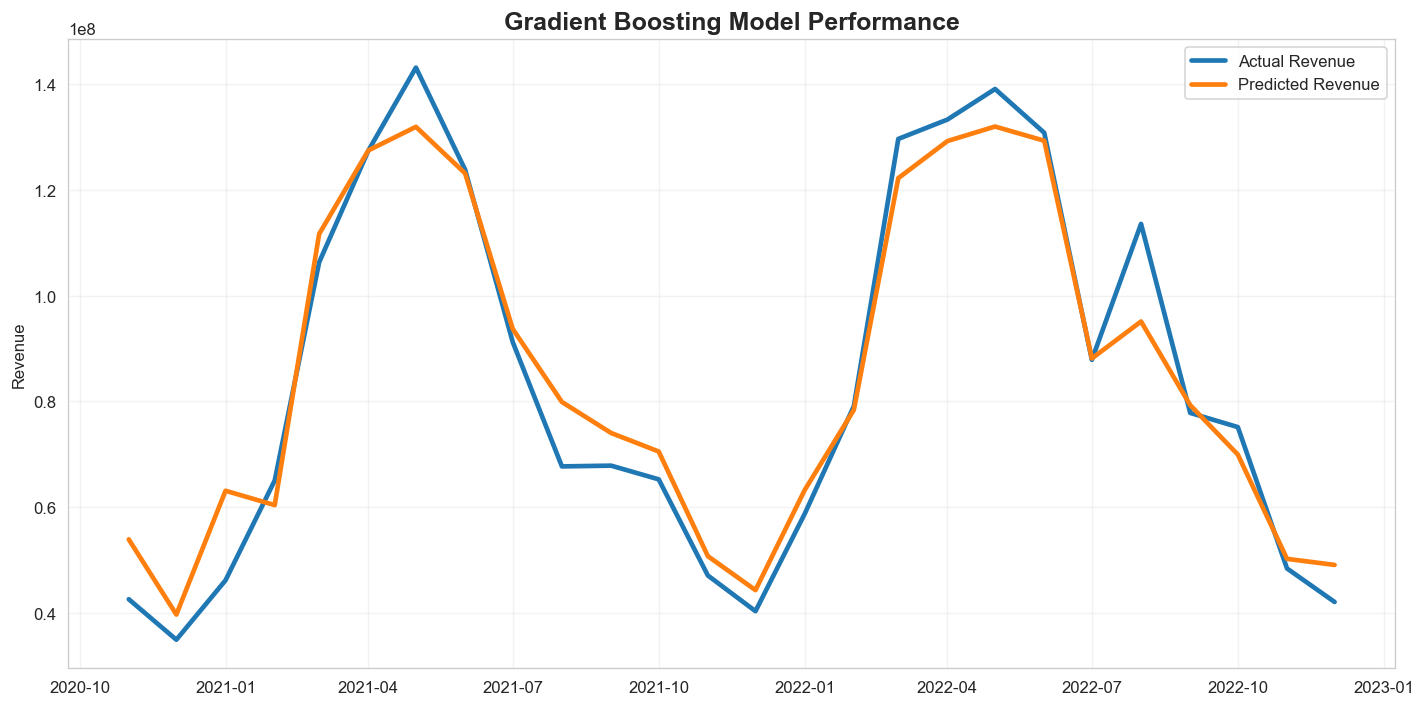

In [77]:
result = pd.DataFrame({
    "month": df["month"].iloc[split:].values,
    "Actual Revenue": y_test.values,
    "Predicted Revenue": pred_test
})

plt.figure(figsize=(12,6))

# Actual
plt.plot(
    result["month"],
    result["Actual Revenue"],
    linewidth=2.8,
    label="Actual Revenue"
)

# Predicted
plt.plot(
    result["month"],
    result["Predicted Revenue"],
    linewidth=2.8,
    label="Predicted Revenue"
)

plt.title("Gradient Boosting Model Performance", fontsize=15, weight="bold")
plt.xlabel("")
plt.ylabel("Revenue")

# chữ ngang
plt.xticks(rotation=0)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Hiệu quả mô hình

Đường doanh thu dự báo bám khá sát đường doanh thu thực tế trong phần lớn thời gian, cho thấy mô hình Gradient Boosting đã nắm bắt tốt xu hướng vận động chung và tính mùa vụ của doanh nghiệp.

Mô hình hoạt động hiệu quả ở cả các giai đoạn tăng trưởng mạnh lẫn suy giảm, thể hiện khả năng phản ứng tốt trước sự thay đổi của nhu cầu thị trường.

Một số sai lệch xuất hiện tại các thời điểm doanh thu tăng đột biến, khi doanh thu thực tế cao hơn dự báo. Điều này thường xảy ra do các yếu tố ngắn hạn như chương trình khuyến mãi, chiến dịch marketing hoặc biến động thị trường chưa được phản ánh đầy đủ trong dữ liệu lịch sử.

Nhìn chung, mô hình cho độ tin cậy cao và phù hợp để hỗ trợ dự báo doanh thu ngắn hạn, lập kế hoạch kinh doanh và phân bổ nguồn lực.

## FORECAST NEXT 6 MONTHS

In [78]:
future_rows = []
last_row = df.iloc[-1].copy()

for i in range(1,7):

    next_month = last_row["month"] + pd.DateOffset(months=1)

    row = last_row.copy()
    row["month"] = next_month
    row["year"] = next_month.year
    row["month_num"] = next_month.month
    row["quarter"] = next_month.quarter

    # lag update
    row["rev_lag_1"] = last_row["revenue"]
    row["rev_lag_3_avg"] = df["revenue"].tail(3).mean()
    row["orders_lag_1"] = last_row["orders"]

    X_future = pd.DataFrame([row[features]])
    pred = final_model.predict(X_future)[0]

    row["revenue"] = pred

    future_rows.append(row)
    last_row = row

future_df = pd.DataFrame(future_rows)

future_df[["month","revenue"]]

,month,revenue
125,2023-01-01,7.082238e+07
125,2023-02-01,7.962406e+07
125,2023-03-01,8.002933e+07
125,2023-04-01,8.002933e+07
125,2023-05-01,8.002933e+07
125,2023-06-01,7.952248e+07


## FORECAST CHART

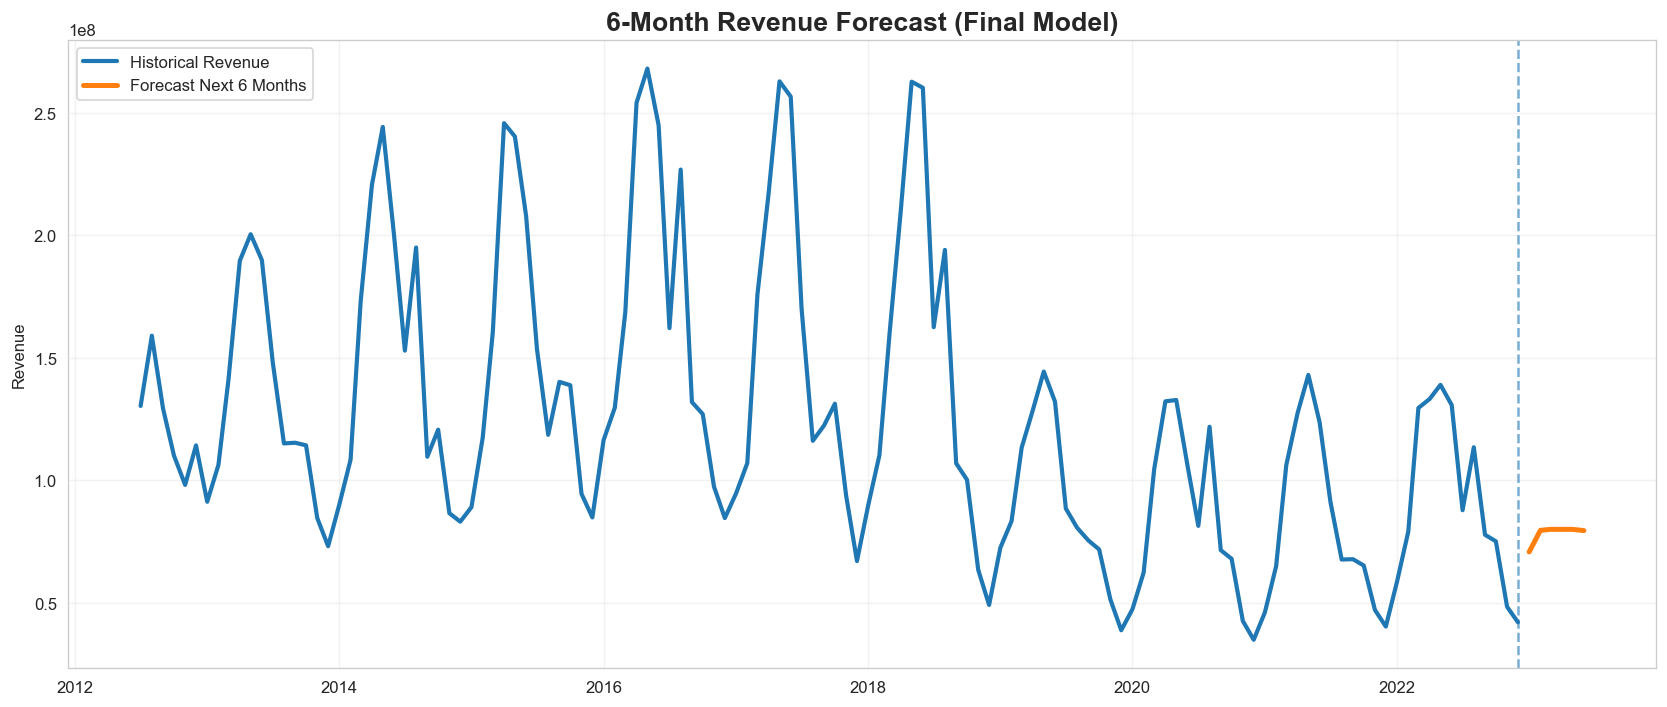

In [79]:
plt.figure(figsize=(14,6))

# Historical Revenue
plt.plot(
    df["month"],
    df["revenue"],
    linewidth=2.5,
    label="Historical Revenue"
)

# Forecast Revenue
plt.plot(
    future_df["month"],
    future_df["revenue"],
    linewidth=3,
    label="Forecast Next 6 Months"
)

# Forecast starting point
plt.axvline(
    df["month"].max(),
    linestyle="--",
    alpha=0.6
)

plt.title("6-Month Revenue Forecast (Final Model)", fontsize=16, weight="bold")
plt.xlabel("")
plt.ylabel("Revenue")

# chữ nằm ngang
plt.xticks(rotation=0)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Dự báo 6 tháng tới

Kết quả dự báo cho thấy doanh thu trong 6 tháng tiếp theo có xu hướng ổn định quanh mức hiện tại, không xuất hiện tín hiệu tăng trưởng đột biến cũng như suy giảm mạnh trong ngắn hạn.

Sau giai đoạn biến động lớn ở các năm trước, doanh nghiệp đang bước vào trạng thái tăng trưởng chậm hơn và doanh thu có xu hướng đi ngang. Điều này cho thấy động lực tăng trưởng hiện tại chưa đủ mạnh để tạo ra bước nhảy doanh thu mới.

Nếu doanh nghiệp không có thay đổi đáng kể về marketing, mở rộng khách hàng hoặc cải thiện năng lực cung ứng, doanh thu nhiều khả năng sẽ tiếp tục duy trì ở mức trung bình như hiện tại.

Về mặt kinh doanh, đây là tín hiệu cần chủ động tạo tăng trưởng mới thay vì chỉ duy trì vận hành hiện tại. Trọng tâm nên là tăng tỷ lệ mua lại, nâng hiệu quả chuyển đổi khách hàng mới và cải thiện khả năng đáp ứng tồn kho ở các nhóm sản phẩm có nhu cầu cao.

## FEATURE IMPORTANCE

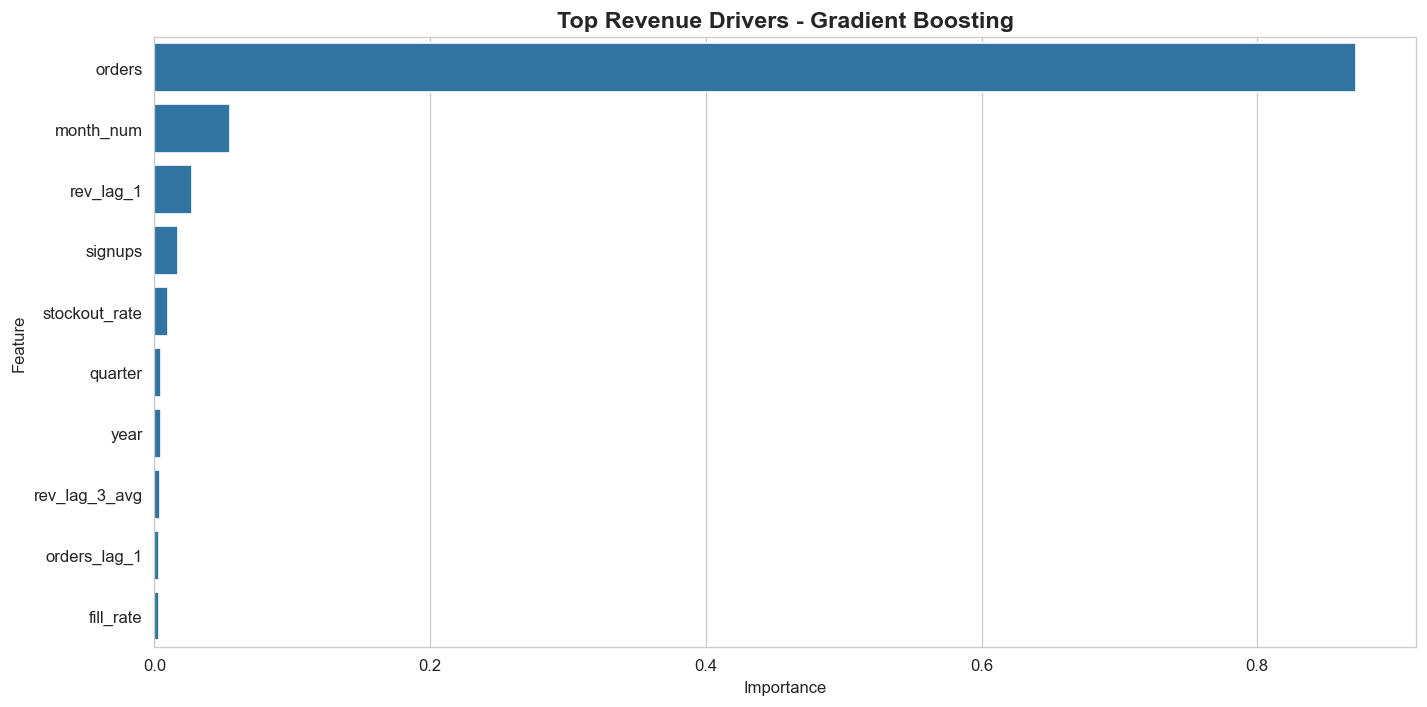

,Feature,Importance
0,orders,0.871585
5,month_num,0.054595
7,rev_lag_1,0.027424
1,signups,0.016733
2,stockout_rate,0.009553
6,quarter,0.004819
4,year,0.004465
8,rev_lag_3_avg,0.004254
9,orders_lag_1,0.003374
3,fill_rate,0.003198


In [80]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": final_model.feature_importances_
}).sort_values("Importance", ascending=False)

sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Top Revenue Drivers - Gradient Boosting", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

importance

### Các yếu tố tác động doanh thu

Kết quả Feature Importance cho thấy **orders (số lượng đơn hàng)** là yếu tố ảnh hưởng lớn nhất đến doanh thu, vượt trội so với tất cả biến còn lại. Điều này hoàn toàn hợp lý vì doanh thu ngắn hạn phụ thuộc trực tiếp vào khả năng tạo ra đơn hàng mỗi tháng.

Yếu tố quan trọng tiếp theo là **month_num**, cho thấy doanh thu có tính mùa vụ rõ rệt theo từng tháng trong năm. Nói cách khác, có những giai đoạn doanh thu thường cao hơn hoặc thấp hơn theo chu kỳ lặp lại.

Biến **rev_lag_1** cũng có tác động đáng kể, cho thấy doanh thu tháng trước là tín hiệu mạnh để dự báo doanh thu tháng sau. Điều này phản ánh tính liên tục trong hành vi kinh doanh và nhu cầu thị trường.

Trong khi đó, **signups**, **stockout_rate** và **fill_rate** có mức ảnh hưởng thấp hơn nhưng vẫn mang giá trị hỗ trợ. Các biến này cho thấy thu hút khách hàng mới và hiệu quả vận hành tồn kho vẫn góp phần tác động đến doanh thu, dù không mạnh bằng số lượng đơn hàng thực tế.

Về góc độ kinh doanh, doanh nghiệp muốn tăng doanh thu nên ưu tiên tăng số đơn hàng, tận dụng mùa cao điểm và duy trì ổn định hiệu suất bán hàng qua từng tháng.

## TỔNG KẾT

1. Doanh nghiệp đang thu hút khách hàng mới khá tốt.
   - Số lượng đăng ký mới tăng đều theo thời gian.

2. Vấn đề chính phía Demand là chuyển đổi còn yếu.
   - Nhiều người đăng ký nhưng đơn hàng và mua lại chưa tăng tương xứng.

3. Vấn đề chính phía Supply là phân bổ tồn kho chưa hợp lý.
   - Một số nhóm sản phẩm nhu cầu cao bị thiếu hàng, trong khi nhóm khác tồn dư.

4. Mô hình dự báo tốt nhất được chọn sau khi so sánh 5 mô hình.
   - Gradient Boosting đạt:
     + RMSE: 7.41 triệu
     + R² : 0.955

5. Dự báo 6 tháng tới cho thấy doanh thu có xu hướng đi ngang.
   - Chưa có tín hiệu tăng trưởng mạnh nếu không thay đổi chiến lược.

6. Ưu tiên hành động:
   - Tăng tỷ lệ chuyển đổi từ đăng ký sang mua hàng
   - Tăng tỷ lệ khách hàng quay lại
   - Tối ưu tồn kho cho nhóm sản phẩm nhu cầu cao
   - Ứng dụng dự báo vào kế hoạch doanh thu và ngân sách